# Distributions and sampling

CPU companion; no accelerator is required. TPU execution not validated.

- Distinguish samples, density, variance and standard error
- Check normal moments against independent analytic expectations
- Use log-space arithmetic for an extreme mixture likelihood
- Demonstrate both key replay and independent split-key draws

A sensor model says that a future reading has mean $2$ and standard deviation $3$. What should a finite collection of simulated readings look like, and how can we check our simulator? We will compare independent formulas with JAX samples, then deliberately underflow a likelihood calculation. This is the numerical foundation for the Bayesian model in the next lesson.

## The idea

A probability distribution describes possible outcomes and their relative plausibility. Sampling produces individual outcomes; a density evaluates a candidate outcome. For a continuous distribution, density is not the probability of exactly that point. Probability comes from integrating density over an interval. We work in float32 on CPU and keep random keys explicit so an experiment can be replayed.

## Start with units, not an API

A standard deviation has the same units as a sensor reading. Variance has squared units. To change a standard-normal draw $z$ into a reading, multiply by the standard deviation and add the mean: $x=2+3z$. The expected variance is $9$, not $3$. This is why the scale parameter in our log-density divides the residual before squaring. We assume a strictly positive finite scale; validation belongs at a public input boundary.

$$
p(x\mid\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\left[-\frac12\left(\frac{x-\mu}{\sigma}\right)^2\right],\quad \sigma>0
$$

## One draw and a sample average answer different questions

A single future reading has standard deviation $3$. An average of $N$ independent readings has standard error $3/\sqrt{N}$. More simulation improves an estimate of the model mean; it does not make the next sensor reading less noisy. At $N=20000$, the mean standard error is about $0.0212$. Our deterministic seeded test uses a generous five-standard-error bound and a separate variance check. A statistical tolerance can fail by chance for other seeds, so keep the seed, sample size and actual discrepancy.

## Logarithms preserve ratios that densities lose

A normal log-density is a negative quadratic plus normalization terms. Summing log-densities for independent observations avoids multiplying many small values. A mixture is different: it adds weighted densities, so we use log-sum-exp rather than summing component log-densities. For equal components with log-densities $-1000$ and $-1001$, subtracting the maximum before exponentiation preserves their relative contribution. The ordinary density may still be too small to represent, but its log remains finite.

$$
\log\!\left(\frac{e^a+e^b}{2}\right)=m+\log(e^{a-m}+e^{b-m})-\log 2,\quad m=\max(a,b)
$$

## A random key is part of the experiment

Calling a random function twice with the same key and shape replays the same values in this tested environment. It does not create two independent samples. Split the key before assigning it to separate draws. NumPy and JAX need not return matching random arrays for the same integer seed: compare distributional properties, not bit patterns across libraries. Our sample checks establish a small numerical example, not a universal test of a random-number generator.

## 1. Define a density and its contract

Create main.py in the activated CPU environment. Add the imports and the scalar normal log-density. A scale is a positive standard deviation, not a variance.

In [1]:
import math
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

def normal_logpdf(value, loc, scale):
    return -0.5*((value-loc)/scale)**2 - jnp.log(scale) - 0.5*jnp.log(2*jnp.pi)

The normalization term matters when comparing different scales; the squared residual alone is not a density.

## 2. Sample with explicit ownership

Append the sampler. Split one parent key before drawing two samples; retain each array so replay and variation can be checked.

In [2]:
key_a, key_b = jax.random.split(jax.random.key(23))
a = 2. + 3.*jax.random.normal(key_a, (20000,))
b = 2. + 3.*jax.random.normal(key_b, (20000,))
expected_mean, expected_variance = 2., 9.
assert abs(float(a.mean())-expected_mean) < 5*3/math.sqrt(a.size)
assert abs(float(a.var())-expected_variance) < .4
assert not jnp.array_equal(a,b)
assert jnp.array_equal(a, 2.+3.*jax.random.normal(key_a,(20000,)))

The broad mean bound is five analytic standard errors for this independent normal sample; it is not a guarantee for arbitrary Monte Carlo samples.

## 3. Compare an independent calculation

Append the independent scalar reference and stable mixture calculation, then run python main.py. Inspect the density, mean and variance.

In [3]:
actual = normal_logpdf(jnp.array([2.,5.]),2.,3.)
reference = [-math.log(3*math.sqrt(2*math.pi)), -.5-math.log(3*math.sqrt(2*math.pi))]
np.testing.assert_allclose(actual,reference,rtol=1e-6)
components = jnp.array([-1000.,-1001.])
stable = logsumexp(components)-jnp.log(2.)
assert jnp.isfinite(stable)
assert jnp.isneginf(jnp.log(jnp.exp(components).mean()))
print('sample mean, variance:',float(a.mean()),float(a.var()))
print('stable equal-mixture log density:',float(stable))

sample mean, variance: 2.0067408084869385 9.035282135009766
stable equal-mixture log density: -1000.3799438476562


A log density near negative one thousand remains representable even when exponentiating it underflows in float32.

## Run the example

In [4]:
import math
import numpy as np
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp

def normal_logpdf(value, loc, scale):
    return -0.5*((value-loc)/scale)**2 - jnp.log(scale) - 0.5*jnp.log(2*jnp.pi)

key_a, key_b = jax.random.split(jax.random.key(23))
a = 2. + 3.*jax.random.normal(key_a, (20000,))
b = 2. + 3.*jax.random.normal(key_b, (20000,))
expected_mean, expected_variance = 2., 9.
assert abs(float(a.mean())-expected_mean) < 5*3/math.sqrt(a.size)
assert abs(float(a.var())-expected_variance) < .4
assert not jnp.array_equal(a,b)
assert jnp.array_equal(a, 2.+3.*jax.random.normal(key_a,(20000,)))

actual = normal_logpdf(jnp.array([2.,5.]),2.,3.)
reference = [-math.log(3*math.sqrt(2*math.pi)), -.5-math.log(3*math.sqrt(2*math.pi))]
np.testing.assert_allclose(actual,reference,rtol=1e-6)
components = jnp.array([-1000.,-1001.])
stable = logsumexp(components)-jnp.log(2.)
assert jnp.isfinite(stable)
assert jnp.isneginf(jnp.log(jnp.exp(components).mean()))
print('sample mean, variance:',float(a.mean()),float(a.var()))
print('stable equal-mixture log density:',float(stable))

sample mean, variance: 2.0067408084869385 9.035282135009766
stable equal-mixture log density: -1000.3799438476562


Expected: The sample mean is close to $2$, the variance is close to $9$, and the stable mixture log-density is approximately $-1000.38$.

## A precise mean does not remove observation noise

Predict: Which band shrinks when we increase the number of independent observations?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
sizes = np.array([1,4,16,64,100,400])
visual_data = {"kind":"line","x":sizes.tolist(),"xlabel":"independent observations N","ylabel":"standard deviation (reading units)","xscale":"log","series":[{"label":"individual reading","y":[3.]*len(sizes)},{"label":"average of N readings","y":(3/np.sqrt(sizes)).tolist()}]}

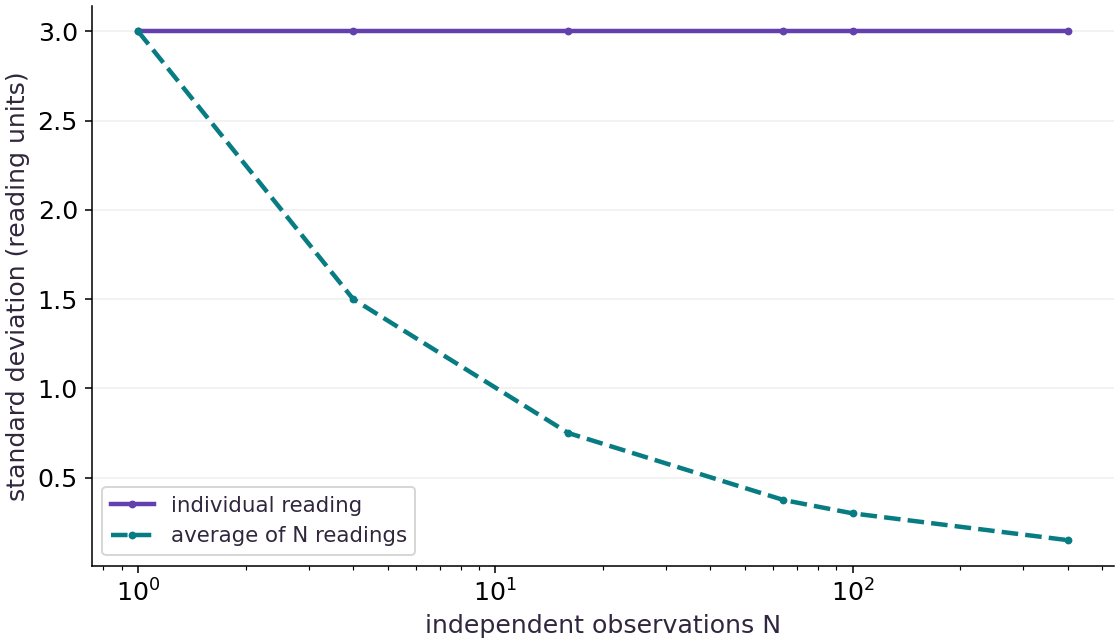

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the number of independent observations on a logarithmic scale: equal spacing represents equal ratios of sample sizes. The vertical axis is the standard deviation in sensor-reading units. The flat curve stays at $3$: it describes one reading. The decreasing curve is $3/\sqrt{N}$: it describes the average of $N$ readings. At $N=100$, the average has standard deviation $0.3$, ten times smaller than an individual reading. These curves are analytic quantities evaluated by the executed example, not measured coverage intervals.

### Connect it to the computation

The two curves explain the mean test in our code. A large simulation can estimate the distribution mean accurately while predictions for new sensor values remain noisy. Correlated draws, such as the Markov chains later in this phase, do not satisfy the same independent-sample calculation unchanged.

## Density can exceed one

Predict: For a normal with standard deviation $0.1$, can its density at its mean exceed $1$?

In [7]:
peak = jnp.exp(normal_logpdf(0.,0.,.1))
assert peak > 1
print("peak density:",float(peak))

peak density: 3.9894230365753174


Expected: The peak density is approximately $3.99$.

A narrow continuous density can exceed one; its area, not its height at a point, sums to one.

## Separate sum and mixture

Predict: Do two independent observations with log densities $-2,-3$ have the same log likelihood as one equal mixture of those components?

In [8]:
values = jnp.array([-2.,-3.])
independent_log = values.sum()
mixture_log = logsumexp(values)-jnp.log(2.)
assert jnp.allclose(independent_log,-5.)
assert mixture_log > -3.
print(float(independent_log),float(mixture_log))

-5.0 -2.379885673522949


Expected: The independent joint log likelihood is $-5$; the mixture log density is approximately $-2.38$.

Independence multiplies probabilities, while alternative mixture components add weighted probabilities.

## Your exercise

Change the sensor to mean $-1$, standard deviation $0.5$, and draw $30000$ readings from a new key. Predict the variance and the standard error of the sample mean, then verify both moments.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
changed = -1.+.5*jax.random.normal(jax.random.key(51),(30000,))
assert abs(float(changed.mean())+1.) < 5*.5/math.sqrt(30000)
assert abs(float(changed.var())-.25) < .015

## Detect a missing normalization · Transfer / diagnosis

Compare scales $1$ and $2$ at their common mean. Show why a residual-only objective incorrectly ties them.

Hint: The residual is zero for both; retain $-\log\sigma$.

In [11]:
# Write your attempt here.

## Reference reasoning

Scale changes density even with identical zero residuals.

In [12]:
scores = normal_logpdf(0.,0.,jnp.array([1.,2.]))
assert jnp.allclose(scores[0]-scores[1],jnp.log(2.))

## Demonstrate key ownership · Transfer / diagnosis

Produce two separately owned standard-normal draws and show replay of the first. Explain why replay alone does not test independence.

Hint: Split before use; compare arrays with the same shape.

In [13]:
# Write your attempt here.

## Reference reasoning

Different split keys avoid accidental replay; one differing pair does not prove every statistical property of a generator.

In [14]:
left,right = jax.random.split(jax.random.key(17))
first = jax.random.normal(left,(32,))
second = jax.random.normal(right,(32,))
assert jnp.array_equal(first,jax.random.normal(left,(32,)))
assert not jnp.array_equal(first,second)

## Checkpoint

Which statement explains why a large Monte Carlo sample can have a precise mean while individual readings remain variable?

1. Every sample becomes equal to the mean as sample size increases
2. The variance of each reading is divided by the sample size
3. The standard error of the average decreases, while the distribution of an individual reading stays the same

## Diagnose

If the simulated variance is near three instead of nine, inspect whether you multiplied by sqrt$3$ when the stated scale was three. If two supposedly independent arrays match exactly, inspect key reuse before changing the distribution. If a mixture likelihood becomes negative infinity, compare the log-sum-exp result before widening dtype.

## Evidence

Seeded arrays, independent density values, moment discrepancies and underflow diagnosis. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- A density is not a point probability.
- Moment checks need sample size, units and a justified tolerance.
- Log-space arithmetic and explicit keys make likelihood experiments inspectable.

## Primary references

- [JAX explicit random keys](https://docs.jax.dev/en/latest/random-numbers.html)
- [JAX logsumexp](https://docs.jax.dev/en/latest/_autosummary/jax.scipy.special.logsumexp.html)